# TEM Projector Simplified Zoom Model (No DAC)

This notebook uses the simplified projector model path in `temgym_core.projector_model`.

It ignores DAC curves and solves directly from:

- approximate geometry distances,
- strong objective and projector lenses (`~2 mm` focal length),
- weaker IL1/IL2/IL3 zoom-lens behavior,
- constraints on magnification, `B = 0`, and zero image rotation.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from temgym_core.projector_model import (
    ProjectorGeometry,
    solve_simplified_projector_zoom,
    realize_simplified_projector_setting,
    build_simplified_projector_components,
    export_simplified_projector_model_json,
    load_simplified_projector_model_json,
)
from temgym_core.source import make_waist_divergence_rays
from temgym_core.plotting import plot_model, legacy_beam_plot_params
from temgym_core.ray import Ray

%matplotlib widget

## Targets And Geometry

Edit distances below to your approximate column geometry.


In [2]:
# Magnifications you provided
TARGET_MAGS = np.array([
    2000, 2500, 3000, 4000, 5000, 6000, 8000, 10000, 12000, 15000,
    20000, 25000, 30000, 40000, 50000, 60000, 80000, 100000, 120000, 150000,
    200000, 250000, 300000, 400000, 500000, 600000, 800000, 1000000, 1200000,
    1500000, 2000000
], dtype=float)

# Approximate projector section geometry (editable)
geometry = ProjectorGeometry(
    d_object_to_opl_m=0.002,
    d_opl_to_il1_m=0.100,
    d_il1_to_il2_m=0.2,
    d_il2_to_il3_m=0.1,
    d_il3_to_pl1_m=0.2,
    d_pl1_to_detector_m=0.400,
)

print('Target magnification count:', len(TARGET_MAGS))
print('Min/Max targets:', TARGET_MAGS.min(), TARGET_MAGS.max())
print('Total modeled length [m]:', geometry.total_length_m())


Target magnification count: 31
Min/Max targets: 2000.0 2000000.0
Total modeled length [m]: 1.0020000000000002


## Solve Simplified Projector Zoom Model

Defaults enforce strong OPL/PL (`2 mm`) and weaker IL lenses.

If many settings are marked unsuccessful, relax/tune:

- geometry distances,
- `il_current_bounds_at`,
- `weak_min_ratio`,
- `max_nfev`.


In [3]:
model = solve_simplified_projector_zoom(
    target_magnifications=TARGET_MAGS,
    geometry=geometry,
    variable_projector_current=True,
    projector_current_bounds_at=(1000.0, 60000.0),
    b_weight=10.0,
    b_weight_relaxed=10.0,
    ffp_weight=1.0,
    ffp_tolerance_m=5e-5,
    n_starts_per_setting=12,
    max_nfev=5000,
)

print('Model type:', model.model_type)
print('Solver info:')
for k, v in model.solver_info.items():
    print(f'  {k}: {v}')


Model type: tem_projector_simplified_zoom_v1
Solver info:
  n_settings: 31
  n_success: 18
  success_fraction: 0.5806451612903226
  mag_tolerance_pct: 2.0
  b_tolerance_m: 5e-05
  weak_min_focal_m: 0.0022
  variable_projector_current: True
  projector_current_bounds_at: [1000.0, 60000.0]
  ffp_weight: 1.0
  ffp_tolerance_m: 5e-05
  solver_method: lm
  n_starts_per_setting: 12
  b_weight: 10.0
  b_weight_relaxed: 10.0
  n_relaxed_rows: 0


## Fit Table Diagnostics


In [4]:
rows = model.fit_table
m_target = np.array([r['magnification_target'] for r in rows], dtype=float)
m_pred = np.array([r['magnification_predicted'] for r in rows], dtype=float)
err_pct = np.array([r['magnification_error_pct'] for r in rows], dtype=float)
B_vals = np.array([r['B'] for r in rows], dtype=float)
psi_vals = np.array([r['psi_total'] for r in rows], dtype=float)
success = np.array([bool(r['success']) for r in rows], dtype=bool)

print('Successful settings:', int(success.sum()), '/', len(success))
print('Median |magnification error| [%]:', float(np.median(np.abs(err_pct))))
print('Max |B| [m]:', float(np.max(np.abs(B_vals))))
print('Max |psi| [rad]:', float(np.max(np.abs(psi_vals))))

for r in rows[:5]:
    print(
        f"M={r['magnification_target']:.0f} "
        f"pred={r['magnification_predicted']:.1f} "
        f"err%={r['magnification_error_pct']:.3f} "
        f"B={r['B']:.3e} psi={r['psi_total']:.3e} "
        f"ok={r['success']}"
    )


Successful settings: 18 / 31
Median |magnification error| [%]: 0.04177072921116633
Max |B| [m]: 7.127902972570155e-05
Max |psi| [rad]: 0.0
M=2000 pred=2000.0 err%=0.002 B=-3.010e-07 psi=0.000e+00 ok=True
M=2500 pred=2500.0 err%=-0.000 B=4.792e-08 psi=0.000e+00 ok=True
M=3000 pred=3000.0 err%=-0.000 B=4.357e-08 psi=0.000e+00 ok=True
M=4000 pred=4000.0 err%=-0.000 B=6.361e-08 psi=0.000e+00 ok=True
M=5000 pred=5000.0 err%=-0.001 B=-4.992e-08 psi=0.000e+00 ok=True


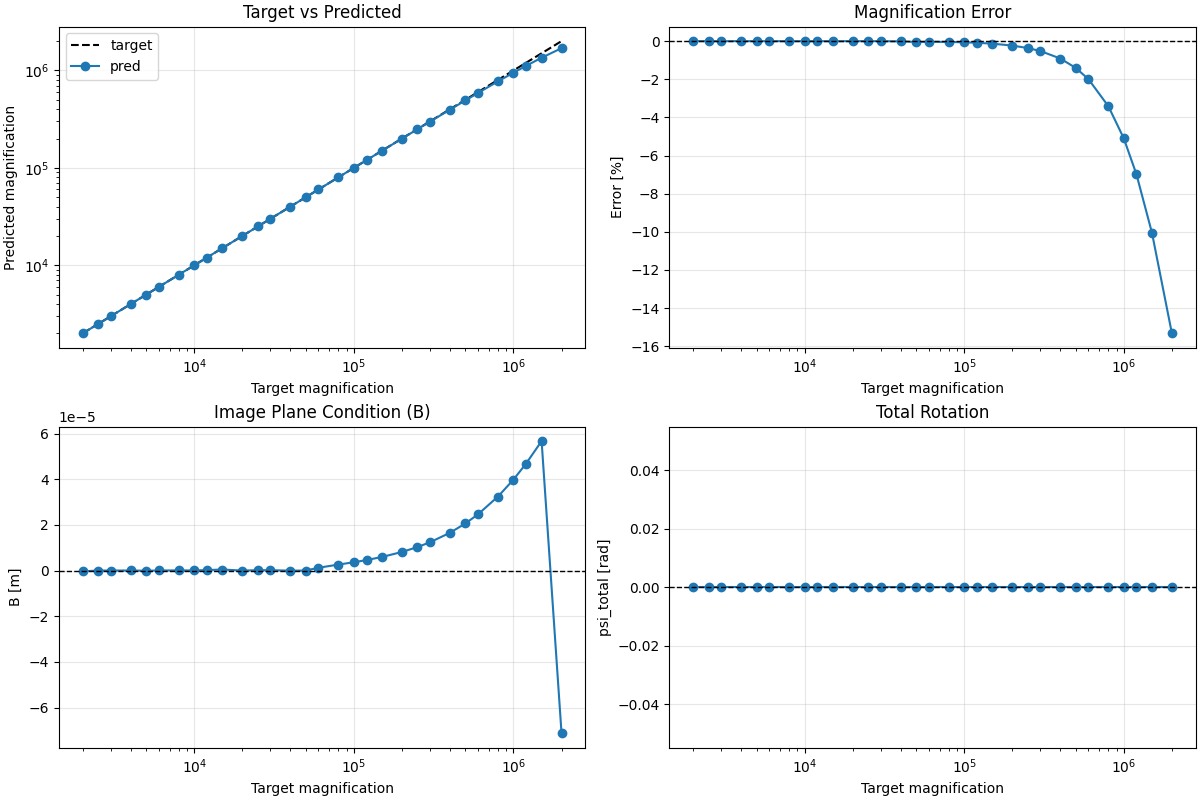

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axs[0, 0].plot(m_target, m_target, 'k--', label='target')
axs[0, 0].plot(m_target, m_pred, 'o-', label='pred')
axs[0, 0].set_xscale('log')
axs[0, 0].set_yscale('log')
axs[0, 0].set_xlabel('Target magnification')
axs[0, 0].set_ylabel('Predicted magnification')
axs[0, 0].set_title('Target vs Predicted')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

axs[0, 1].plot(m_target, err_pct, 'o-')
axs[0, 1].axhline(0.0, color='k', lw=1, ls='--')
axs[0, 1].set_xscale('log')
axs[0, 1].set_xlabel('Target magnification')
axs[0, 1].set_ylabel('Error [%]')
axs[0, 1].set_title('Magnification Error')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].plot(m_target, B_vals, 'o-')
axs[1, 0].axhline(0.0, color='k', lw=1, ls='--')
axs[1, 0].set_xscale('log')
axs[1, 0].set_xlabel('Target magnification')
axs[1, 0].set_ylabel('B [m]')
axs[1, 0].set_title('Image Plane Condition (B)')
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].plot(m_target, psi_vals, 'o-')
axs[1, 1].axhline(0.0, color='k', lw=1, ls='--')
axs[1, 1].set_xscale('log')
axs[1, 1].set_xlabel('Target magnification')
axs[1, 1].set_ylabel('psi_total [rad]')
axs[1, 1].set_title('Total Rotation')
axs[1, 1].grid(True, alpha=0.3)

plt.show()


## Lens Current Curves


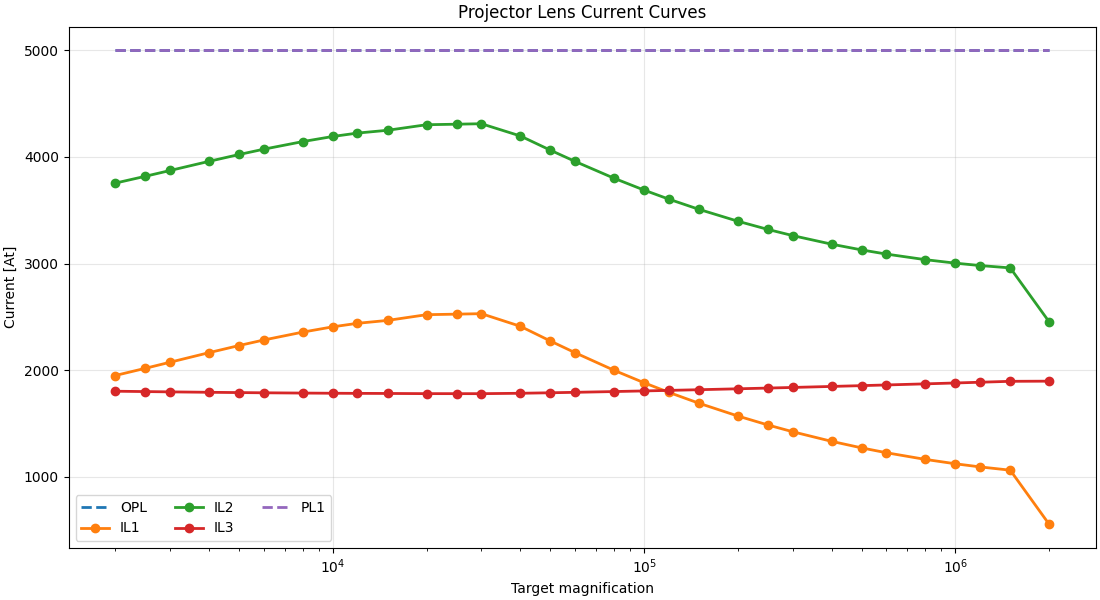

In [6]:
rows = model.fit_table

m_vals = np.array([r['magnification_target'] for r in rows], dtype=float)

i_opl = np.full_like(m_vals, float(model.objective_current_at), dtype=float)
i_il1 = np.array([r['I0_IL1_at'] for r in rows], dtype=float)
i_il2 = np.array([r['I0_IL2_at'] for r in rows], dtype=float)
i_il3 = np.array([r['I0_IL3_at'] for r in rows], dtype=float)
i_pl1 = np.full_like(m_vals, float(model.projector_current_at), dtype=float)

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

ax.plot(m_vals, i_opl, '--', lw=2, label='OPL')
ax.plot(m_vals, i_il1, 'o-', lw=2, label='IL1')
ax.plot(m_vals, i_il2, 'o-', lw=2, label='IL2')
ax.plot(m_vals, i_il3, 'o-', lw=2, label='IL3')
ax.plot(m_vals, i_pl1, '--', lw=2, label='PL1')

ax.set_xscale('log')
ax.set_xlabel('Target magnification')
ax.set_ylabel('Current [At]')
ax.set_title('Projector Lens Current Curves')
ax.grid(True, alpha=0.3)
ax.legend(ncol=3)

plt.show()



## Realize A Specific Magnification


In [7]:
requested_mag = 100000.0
realized = realize_simplified_projector_setting(
    model,
    magnification=requested_mag,
    mode='solve',  # 'solve', 'interpolate', or 'nearest'
)

print('Requested:', requested_mag)
print('Predicted:', realized['magnification_predicted'])
print('B:', realized['B'])
print('psi_total:', realized['psi_total'])
print('IL currents [AT]:', realized['currents_il_at'])
print('IL focals [mm]:', 1e3 * realized['focals_il_m'])
print('weak_constraint_ok:', realized['weak_constraint_ok'])
print('i3_bounds_ok:', realized['i3_bounds_ok'])


Requested: 100000.0
Predicted: 99940.35981906489
B: 3.6398796510184184e-06
psi_total: 0.0
IL currents [AT]: [1882.39644091 3688.51896931 1806.1225284 ]
IL focals [mm]: [38.09882505 11.90723629 60.69749538]
weak_constraint_ok: True
i3_bounds_ok: True


## Build TemGym Components


In [8]:
components = build_simplified_projector_components(
    model,
    magnification=requested_mag,
    mode='solve',
)

print('Component count:', len(components))
for c in components:
    name = type(c).__name__
    if hasattr(c, 'focal_length') and hasattr(c, 'rotation_angle'):
        print(
            f'  {name:20s} z={float(c.z):.6f} m '
            f'f={float(c.focal_length):.6e} m psi={float(c.rotation_angle):.6f} rad'
        )
    else:
        print(f'  {name:20s} z={float(c.z):.6f} m')


Component count: 6
  ElectromagneticLens  z=0.002000 m f=2.000000e-03 m psi=0.000000 rad
  ElectromagneticLens  z=0.102000 m f=3.809883e-02 m psi=0.997954 rad
  ElectromagneticLens  z=0.302000 m f=1.190724e-02 m psi=-1.955471 rad
  ElectromagneticLens  z=0.402000 m f=6.069750e-02 m psi=0.957517 rad
  ElectromagneticLens  z=0.602000 m f=1.388889e-05 m psi=0.000000 rad
  Plane                z=1.002000 m


## Quick Ray Plot


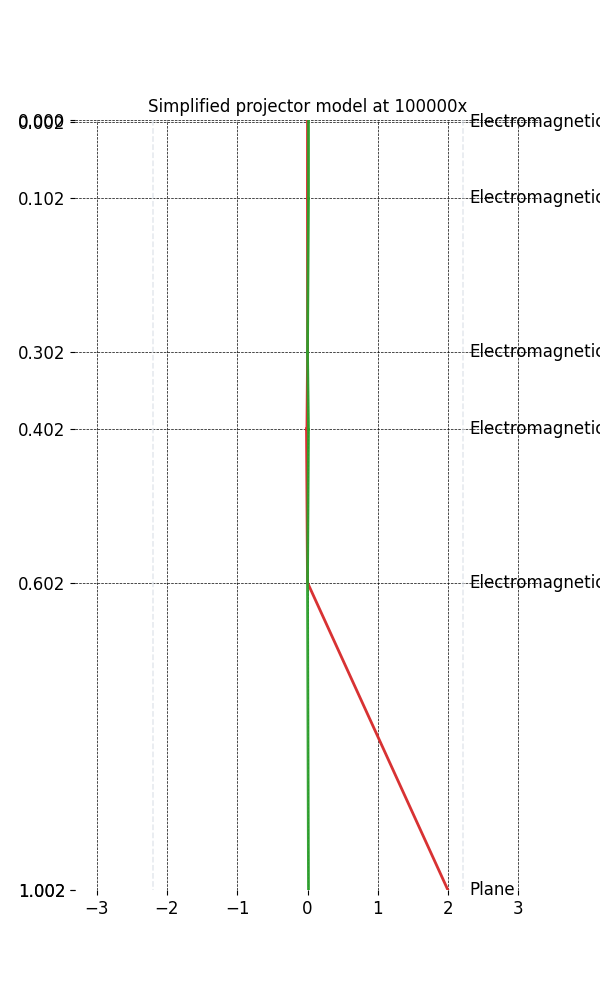

In [9]:
center_ray = Ray.origin()
waist_basis = make_waist_divergence_rays(
    waist=20e-6,
    voltage=model.voltage_v,
    z=0.0,
)

fig, ax = plot_model(
    components,
    rays=center_ray,
    solution_rays=waist_basis,
    include_input_rays=True,
    plot_params=legacy_beam_plot_params()
)
ax.set_title(f'Simplified projector model at {requested_mag:.0f}x')
plt.show()


## Export / Reload


In [10]:
out_path = Path('examples/ray_transfer/exported_microscope_models/projector_simplified_zoom_model.json')
export_simplified_projector_model_json(model, out_path)
loaded = load_simplified_projector_model_json(out_path)

print('Saved:', out_path)
print('Reloaded model type:', loaded.model_type)
print('Reloaded settings:', len(loaded.fit_table))


Saved: examples/ray_transfer/exported_microscope_models/projector_simplified_zoom_model.json
Reloaded model type: tem_projector_simplified_zoom_v1
Reloaded settings: 31
